<KeysViewHDF5 ['extracted_features', 'flux', 'flux_err', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'oid', 'time', 'training_0', 'training_1', 'training_2', 'training_3', 'training_4', 'validation_0', 'validation_1', 'validation_2', 'validation_3', 'validation_4']>


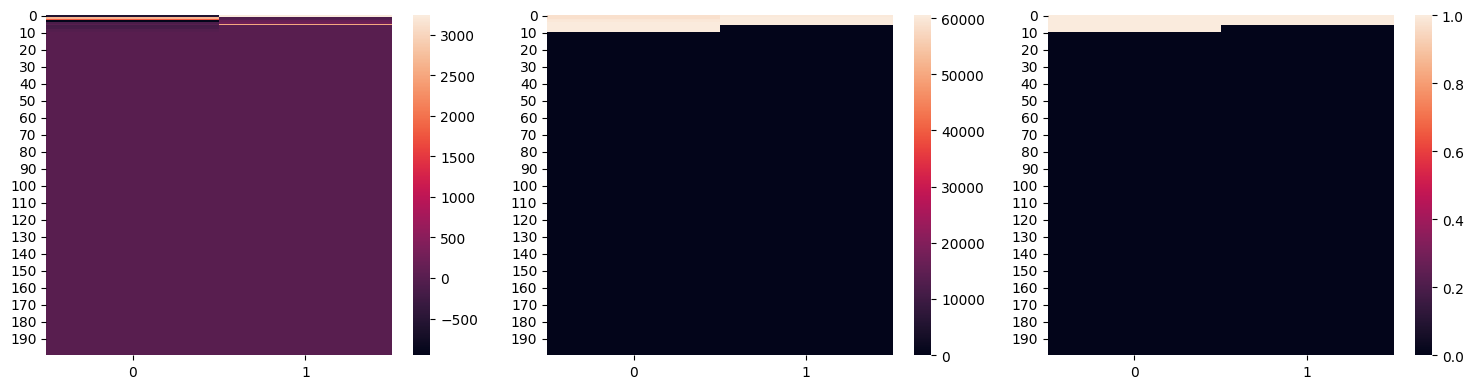

In [24]:
import numpy as np
import pandas as pd
import h5py
import warnings
warnings.filterwarnings("ignore")

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY
import seaborn as sns
dataset  ='validation'
DEVICE = 'cuda:0'
import matplotlib.pyplot as plt

with h5py.File('/home/magdalena/Desktop/sambashare/H5_files/2019/200_2019.h5' , 'r') as f:
    print(f.keys())
    i = np.random.randint(0, 10000)
    flux= f.get('flux')[i]
    time= f.get('time')[i]
    mask= f.get('mask')[i]

    #y = f.get('labels')[:]
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(flux, ax=axes[0])
sns.heatmap(time, ax=axes[1])
sns.heatmap(mask, ax=axes[2])

plt.tight_layout()
plt.show()

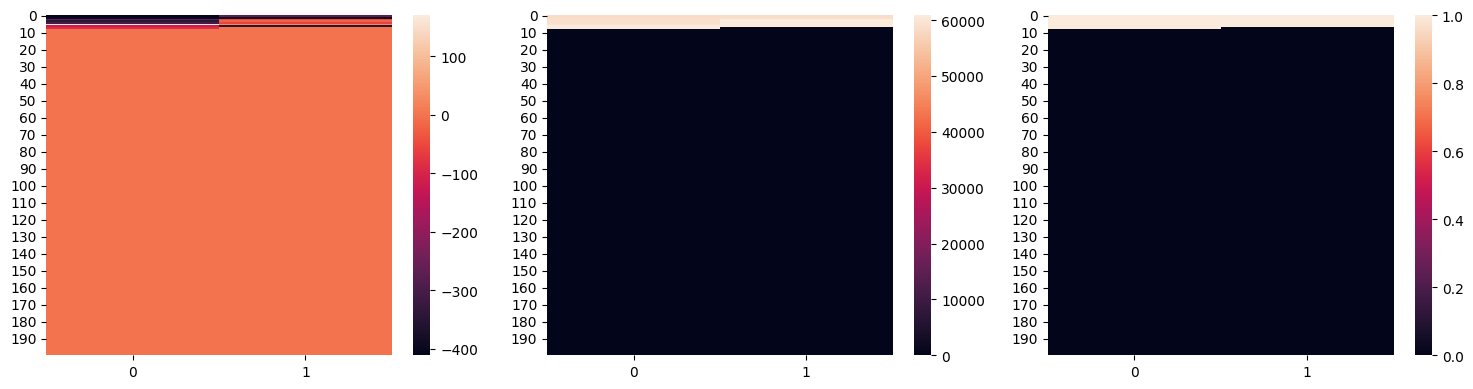

In [109]:
import torch
permutation = torch.randperm(2)
print(permutation)

tensor([0, 1])


0
notusingsampler
tensor([0.0003, 0.0003, 0.0003,  ..., 0.0006, 0.0006, 0.0006],
       dtype=torch.float64)


100%|██████████| 2544/2544 [00:48<00:00, 52.40it/s]


                precision    recall  f1-score   support

           AGN     0.4672    0.4571    0.4621      3288
           QSO     0.6136    0.4813    0.5395      3428
            EA     0.7742    0.7691    0.7717      3500
           YSO     0.5728    0.4880    0.5270      2715
          SNIa     0.4587    0.4198    0.4384      1639
       CV/Nova     0.5610    0.5547    0.5578      1617
          RRLc     0.7423    0.7296    0.7359      3439
         RSCVn     0.5090    0.5821    0.5431      2522
        Blazar     0.2884    0.3424    0.3131      1364
          SNII     0.2884    0.3653    0.3223       802
         EB/EW     0.7128    0.6657    0.6885      3635
           LPV     0.7989    0.7638    0.7810      3319
           CEP     0.6007    0.6357    0.6177      2871
         RRLab     0.8005    0.6042    0.6887      3507
Periodic-Other     0.4021    0.5620    0.4688       742
          DSCT     0.4611    0.6091    0.5248      1604
         SNIbc     0.1229    0.2556    0.1660  

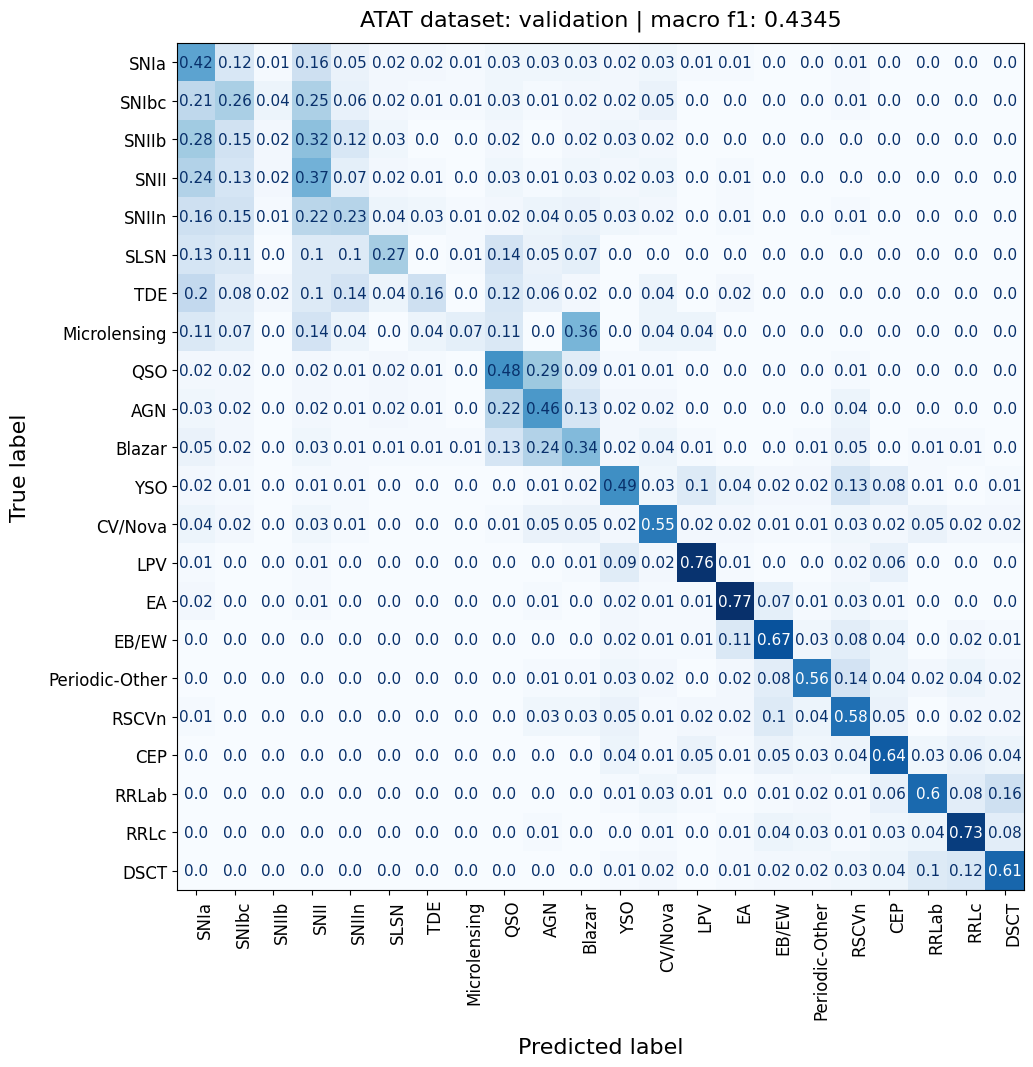

In [2]:
report = test_1.classification_report()

In [3]:
probs, target = test_1.predict_probs()

0
notusingsampler
tensor([0.0003, 0.0003, 0.0003,  ..., 0.0006, 0.0006, 0.0006],
       dtype=torch.float64)


  0%|          | 11/2544 [00:00<01:17, 32.50it/s]

100%|██████████| 2544/2544 [00:45<00:00, 56.16it/s] 


In [4]:
classes = np.argmax(probs, axis = 1)

predictions_df = pd.DataFrame({'predicted_class':classes, 'target':target, 'correct': (abs(classes-target)) == 0})
with h5py.File('data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5', 'r') as f:
    print(f.keys())
    idx = f.get('validation_0')[:]
    snid = f.get("SNID").asstr()[idx]
predictions_df['SNID'] = snid
predictions_df['n_window'] = predictions_df['SNID'].apply(lambda x:x[-1])
these_idx = predictions_df.query('correct == False')

<KeysViewHDF5 ['SNID', 'extracted_feat_1024', 'extracted_feat_128', 'extracted_feat_16', 'extracted_feat_2048', 'extracted_feat_256', 'extracted_feat_32', 'extracted_feat_512', 'extracted_feat_64', 'flux', 'flux_err', 'labels', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'modded_test', 'modded_training_0', 'modded_validation_0', 'test', 'time', 'time_detection', 'time_photometry', 'training_0', 'validation_0']>


In [5]:
predictions_df

,predicted_class,target,correct,SNID,n_window
0,10,10.0,True,ZTF17aaafiww_0,0
1,10,10.0,True,ZTF17aaafiww_1,1
2,10,10.0,True,ZTF17aaafiww_2,2
3,10,10.0,True,ZTF17aaafiww_3,3
4,10,10.0,True,ZTF17aaafiww_4,4
...,...,...,...,...,...
40693,9,4.0,False,ZTF23abcvqkd_1,1
40694,17,4.0,False,ZTF23abcvqkd_2,2
40695,4,4.0,True,ZTF23abcvqkd_3,3
40696,4,4.0,True,ZTF23abcvqkd_4,4


In [6]:
embs, _ = test_1.get_embeddings()

0
notusingsampler
tensor([0.0003, 0.0003, 0.0003,  ..., 0.0006, 0.0006, 0.0006],
       dtype=torch.float64)


100%|██████████| 2544/2544 [00:27<00:00, 92.92it/s] 


In [7]:
these_idx

,predicted_class,target,correct,SNID,n_window
5,7,10.0,False,ZTF17aaafiww_5,5
7,7,10.0,False,ZTF17aaafiww_7,7
9,2,6.0,False,ZTF17aaaizfv_1,1
28,15,10.0,False,ZTF17aabupde_8,8
33,7,10.0,False,ZTF17aabuuyx_3,3
...,...,...,...,...,...
40688,9,4.0,False,ZTF22abnlwjv_6,6
40689,3,4.0,False,ZTF22abnlwjv_7,7
40690,20,9.0,False,ZTF23aadbwtw_0,0
40693,9,4.0,False,ZTF23abcvqkd_1,1


In [8]:
predictions_df.groupby(['target','n_window','correct']).aggregate({'predicted_class':'count', 'SNID':list})

predicted_class  \
target n_window correct                    
0.0    0        False                271   
                True                 278   
       1        False                285   
                True                 243   
       2        False                285   
...                                  ...   
21.0   4        False                  3   
       5        False                  2   
       6        False                  2   
       7        False                  2   
       8        False                  1   

                                                                      SNID  
target n_window correct                                                     
0.0    0        False    [ZTF18aaedrgt_0, ZTF18aaihlnj_0, ZTF19aapvvsp_...  
                True     [ZTF18aayigdr_0, ZTF19aamllje_0, ZTF18aadfaxs_...  
       1        False    [ZTF18aaihlnj_1, ZTF18aayigdr_1, ZTF19aapvvsp_...  
                True     [ZTF18aaedrgt_1, ZTF19aamllje_1, ZTF20aawbzoi_...  
       2        False    [ZTF18aaihlnj_2, ZTF18aayigdr_2, ZTF19aapvvsp_...  
...                                                                    ...  
21.0   4        False     [ZTF18abnbmsr_4, ZTF18aaztjyd_4, ZTF18abmoxlq_4]  
       5        False                     [ZTF18abnbmsr_5, ZTF18aaztjyd_5]  
       6        False                     [ZTF18abnbmsr_6, ZTF18aaztjyd_6]  
       7        False                     [ZTF18abnbmsr_7, ZTF18aaztjyd_7]  
       8        False                                     [ZTF18aaztjyd_8]  

[411 rows x 2 columns]

In [9]:
embs_df = pd.DataFrame(embs)

In [70]:
wrong_embeddings = these_idx.merge(embs_df,left_index=True, right_index=True).reset_index()

In [71]:
wrong_embeddings

,index,predicted_class,target,correct,SNID,n_window,0,1,2,3,...,118,119,120,121,122,123,124,125,126,127
0,5,7,10.0,False,ZTF17aaafiww_5,5,1.274186,0.805511,-2.074584,1.299024,...,-0.010887,1.227427,-1.628971,0.996250,0.640429,1.612878,-1.615528,-1.263372,-2.788103,-0.125168
1,7,7,10.0,False,ZTF17aaafiww_7,7,1.602151,1.135515,-2.021363,1.365246,...,0.365161,0.834728,-1.528723,1.099501,0.732784,1.976250,-1.338022,-1.070186,-2.532708,-0.707727
2,9,2,6.0,False,ZTF17aaaizfv_1,1,1.710557,-0.426540,-1.818722,-0.806096,...,-2.904327,0.503192,-0.294644,-0.753116,-0.617537,1.952006,0.756828,-0.848382,-0.218666,1.485976
3,28,15,10.0,False,ZTF17aabupde_8,8,1.401118,0.734071,0.530224,0.423167,...,-1.187738,2.284439,-0.523285,1.430786,0.537408,1.468005,-0.271661,-0.339661,-1.067441,1.679130
4,33,7,10.0,False,ZTF17aabuuyx_3,3,1.734282,0.806700,-0.086180,1.933661,...,-0.337028,0.694415,-0.990268,1.763843,0.082393,1.730797,-1.716875,0.102652,-0.026791,-0.029228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16756,40688,9,4.0,False,ZTF22abnlwjv_6,6,1.067915,0.187430,-0.840662,0.861021,...,-0.386395,-0.684044,-0.257132,-0.658420,-1.668910,-3.086198,0.645477,-0.559212,1.647654,-0.315199
16757,40689,3,4.0,False,ZTF22abnlwjv_7,7,1.899647,0.209528,-0.211819,2.180453,...,-0.216589,-0.465474,0.447639,-0.623981,-0.165758,-1.287302,2.405603,0.756466,0.738664,-2.386790
16758,40690,20,9.0,False,ZTF23aadbwtw_0,0,-0.564426,0.187375,-0.334474,1.042294,...,-0.753557,-0.435388,-0.126771,-0.617653,1.491388,-0.284642,-0.281539,-0.493639,1.399575,0.515174
16759,40693,9,4.0,False,ZTF23abcvqkd_1,1,3.496099,0.116515,-0.347681,1.283251,...,1.255651,1.757258,0.913840,0.571629,1.718037,-1.024599,2.153745,-0.356899,1.634088,0.798953


In [73]:
cosine_df = wrong_embeddings.drop(columns = ['predicted_class','target','correct', 'SNID','n_window', 'index'])

In [74]:
alignment = cosine_df.values @ cosine_df.values.T
alignment = alignment / abs(alignment).max()

alignment.shape

(16761, 16761)

In [75]:
cosine_df.values.T.shape

(128, 16761)

In [76]:
cosine_df.values.T - (np.triu(np.ones(cosine_df.shape),) * np.tril(np.ones(cosine_df.shape))).T

array([[ 0.2742,  1.6022,  1.7106, ..., -0.5644,  3.4961, -0.3585],
       [ 0.8055,  0.1355, -0.4265, ...,  0.1874,  0.1165, -1.6227],
       [-2.0746, -2.0214, -2.8187, ..., -0.3345, -0.3477, -0.4432],
       ...,
       [-1.2634, -1.0702, -0.8484, ..., -0.4936, -0.3569,  2.6535],
       [-2.7881, -2.5327, -0.2187, ...,  1.3996,  1.6341,  1.6561],
       [-0.1252, -0.7077,  1.486 , ...,  0.5152,  0.799 ,  0.7879]])

In [93]:
def get_most_similar(emb):
    alignment =  emb @ (cosine_df.values.T )
    alignment = alignment / alignment.max()
    return np.argmax(alignment * (alignment != 1))

get_most_similar(cosine_df.iloc[3])

2882

index                          28
predicted_class                15
target                       10.0
correct                     False
SNID               ZTF17aabupde_8
                        ...      
123                      1.468005
124                     -0.271661
125                     -0.339661
126                     -1.067441
127                       1.67913
Name: 3, Length: 134, dtype: object
<KeysViewHDF5 ['SNID', 'extracted_feat_1024', 'extracted_feat_128', 'extracted_feat_16', 'extracted_feat_2048', 'extracted_feat_256', 'extracted_feat_32', 'extracted_feat_512', 'extracted_feat_64', 'flux', 'flux_err', 'labels', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'modded_test', 'modded_training_0', 'modded_validation_0', 'test', 'time', 'time_detection', 'time_photometry', 'training_0', 'validation_0']>
index                          28
predicted_class                15
target                       10.0
correct                     False
SNID               ZT

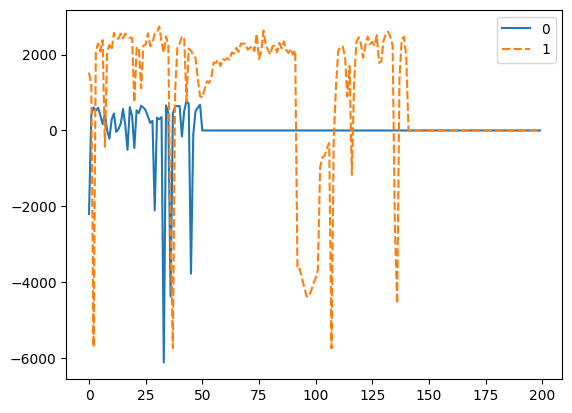

In [97]:
print(wrong_embeddings.iloc[3])
with h5py.File('data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5', 'r') as f:
    print(f.keys())
    print(wrong_embeddings.iloc[3])
    idx_ = wrong_embeddings.iloc[3]['index'].astype(int)
    sns.lineplot(f.get('flux')[idx_])

<KeysViewHDF5 ['SNID', 'extracted_feat_1024', 'extracted_feat_128', 'extracted_feat_16', 'extracted_feat_2048', 'extracted_feat_256', 'extracted_feat_32', 'extracted_feat_512', 'extracted_feat_64', 'flux', 'flux_err', 'labels', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'modded_test', 'modded_training_0', 'modded_validation_0', 'test', 'time', 'time_detection', 'time_photometry', 'training_0', 'validation_0']>
7293


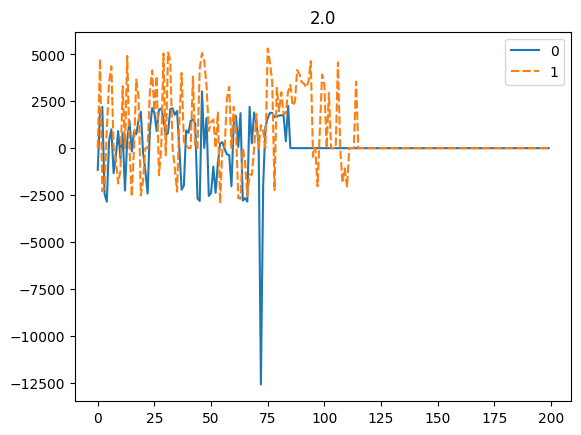

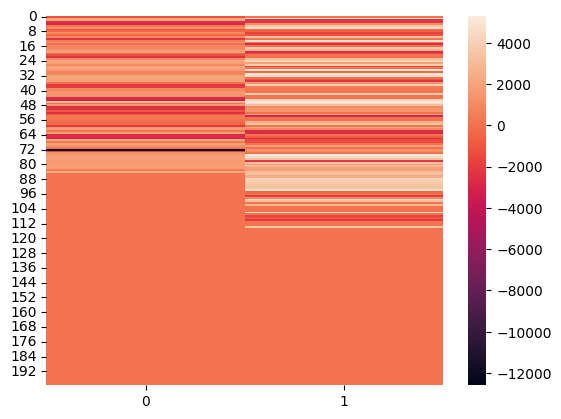

In [92]:
with h5py.File('data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5', 'r') as f:
    print(f.keys())
    i = np.random.randint(0, 1e4)
    print(i)
    i = 41688
    plt.title((f.get('labels')[i]))
    sns.lineplot(f.get('flux')[i])
    plt.show()
    sns.heatmap(f.get('flux')[i])
    v = f.get('flux')[i]

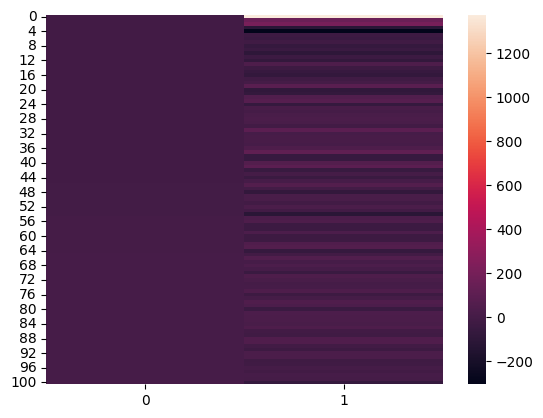

<Axes: >

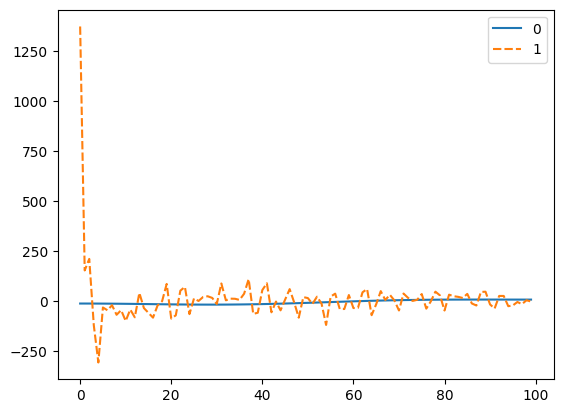

In [86]:
import torch
v = torch.tensor(v)
f = torch.fft.rfft(v, dim = 0, norm = 'forward').float()
#f = f/f.norm(dim = 0,keepdim = True)
#f = torch.nn.functional.softmax(f)
f = f.detach().cpu().numpy()
sns.heatmap(f)
plt.show()
sns.lineplot(f[:100,:])

In [51]:
with h5py.File('data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5', 'r') as f:
    print(f.keys())
    print(wrong_embeddings.iloc[2882])
    idx_ = wrong_embeddings.iloc[2882]['index'].astype(int)
    sns.lineplot(f.get('flux')[idx_])

<KeysViewHDF5 ['SNID', 'extracted_feat_1024', 'extracted_feat_128', 'extracted_feat_16', 'extracted_feat_2048', 'extracted_feat_256', 'extracted_feat_32', 'extracted_feat_512', 'extracted_feat_64', 'flux', 'flux_err', 'labels', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'modded_test', 'modded_training_0', 'modded_validation_0', 'test', 'time', 'time_detection', 'time_photometry', 'training_0', 'validation_0']>


NameError: name 'wrong_embeddings' is not defined

<Axes: >

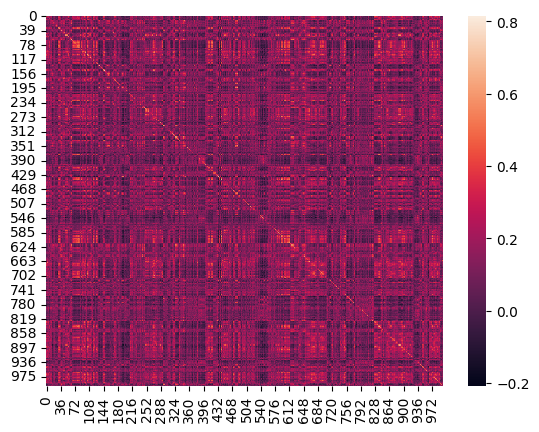

In [ ]:
sns.heatmap(alignment[:100,:100])

In [3]:
probs.shape

(40698, 128)

<KeysViewHDF5 ['SNID', 'extracted_feat_1024', 'extracted_feat_128', 'extracted_feat_16', 'extracted_feat_2048', 'extracted_feat_256', 'extracted_feat_32', 'extracted_feat_512', 'extracted_feat_64', 'flux', 'flux_err', 'labels', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'modded_test', 'modded_training_0', 'modded_validation_0', 'test', 'time', 'time_detection', 'time_photometry', 'training_0', 'validation_0']>


In [1]:
dict = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

In [3]:
from ReportPretraining import QuickLoader

ql = QuickLoader(batch_size = 1,experiment_type="MD").validation

MD


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/mo

notusingsampler
MD
MD


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.5.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


In [ ]:
import torch
class infout:
    def __init__(self, zerout_n = 3):
        self.zerout_n = zerout_n
    def __call__(self, sample):
        #print(sample['tabular_feat'] )
        #sample['tabular_feat'] = sample['tabular_feat'][0,:,:]
        idxs = torch.randint(0,sample['tabular_feat'].size(0),size  = (self.zerout_n,))
        sample['tabular_feat'][idxs] = -1e-12
        print(sample['tabular_feat'])

In [47]:
test = infout()



In [ ]:
for i in ql:
    print(i['tabular_feat'].shape)
    t = i['tabular_feat']
    print(test(i))
    break

/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/data/handlers/CustomDataset.py:150: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data_dict.update({"metadata_feat":torch.tensor(self.metadata_feat[_idx],dtype =  torch.float),})
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/data/handlers/CustomDataset.py:150: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data_dict.update({"metadata_feat":torch.tensor(self.metadata_feat[_idx],dtype =  torch.float),})
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/data/handlers/CustomDataset.py:150: UserWarning: To copy construct from a tensor, it is recommended t

torch.Size([1, 6, 1])
tensor([[[0.3879],
         [0.5414],
         [0.6066],
         [0.4916],
         [0.2808],
         [0.2727]]])
tensor([[-1.0000e-12],
        [ 5.4139e-01],
        [-1.0000e-12],
        [ 4.9164e-01],
        [-1.0000e-12],
        [ 2.7271e-01]])
None


: 

In [ ]:
import seaborn as sns
class ExploreSobel:
    def __init__(self):
        self.magnitude_list,self.sobel_h_list, self.sobel_v_list,self.target = self.generate_sobel_mag_hor_ver()
        df_target = df_target = pd.DataFrame({'target': self.target.astype(int)})
        self.class_indexes = pd.DataFrame({'class':range(0,22),'indexes': [df_target[df_target['target'] == i].index.to_list()  for i in range(0,22)]})

    def generate_sobel_mag_hor_ver(self):
        target = None
        i = 0
        from tqdm import tqdm
        from scipy import ndimage
        import numpy as np
        sobel_h_list = np.empty((len(ql),200,2))# []
        sobel_v_list =np.empty((len(ql),200,2))# []
        magnitude_list = np.empty((len(ql),200,2))# [][]

        for b1 in tqdm(ql):
            #b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
            t = b1['labels'].cpu().detach().numpy()
            signal = b1['data'].detach().cpu().numpy()

            sobel_h = ndimage.sobel(signal, 0) * (signal!=0)
            if sobel_h.max() >1:
                sobel_h = sobel_h/sobel_h.max()
            sobel_h_list[i,:,:] =  sobel_h.squeeze(0)

            sobel_v = ndimage.sobel(signal, 1) * (signal!=0)
            if sobel_v.max() >1:
                sobel_v = sobel_v/sobel_v.max()
            sobel_v_list[i,:,:] =  sobel_v.squeeze(0)

            magnitude = np.sqrt(sobel_h**2 + sobel_v**2)
            magnitude = (magnitude* (signal!=0))
            if magnitude.max() >1:
                magnitude = magnitude/magnitude.max()

            magnitude_list[i,:,:] =  magnitude.squeeze(0)
            target = (
                np.concatenate([target, t])
                if target is not None
                else t
            )
            i +=1
        return magnitude_list,sobel_h_list, sobel_v_list, target

    def plot_mag(self, xlim = (0,1),ylim = (0,60)):
        fig,ax = plt.subplots(11,2,figsize = (40,30))
        ax= ax.flatten()
        for i in range(22):
            if len(self.class_indexes['indexes'].iloc[i]) == 0:
                continue
            mag = self.magnitude_list[self.class_indexes['indexes'].iloc[i]]
            mag = mag.mean(axis = 0)
            sns.histplot(mag,ax = ax[i], bins = 100)
            ax[i].set_title(f'Sobel Magnitude Distribution for {list(dict.keys())[i]}', fontsize=12)
            ax[i].set_ylim(ylim)
            ax[i].set_xlim(xlim)
        plt.tight_layout()
        plt.show()

    def plot_hor(self, xlim = (0,1),ylim = (0,60)):
        fig,ax = plt.subplots(11,2,figsize = (40,30))
        ax= ax.flatten()
        for i in range(22):
            if len(self.class_indexes['indexes'].iloc[i]) == 0:
                continue
            mag = self.sobel_h_list[self.class_indexes['indexes'].iloc[i]]
            mag = mag.mean(axis = 0)

            sns.histplot(mag,ax = ax[i], bins = 1000)
            ax[i].set_title(f'Horizontal Sobel Distribution for {list(dict.keys())[i]}', fontsize=12)
            ax[i].set_ylim(ylim)

            ax[i].set_xlim(xlim)

        plt.tight_layout()
        plt.show()

    def plot_vertical(self, xlim = (0,1),ylim = (0,60)):
        fig,ax = plt.subplots(11,2,figsize = (40,30))
        ax= ax.flatten()
        for i in range(22):
            if len(self.class_indexes['indexes'].iloc[i]) == 0:
                continue
            mag = self.sobel_v_list[self.class_indexes['indexes'].iloc[i]]
            mag = mag.mean(axis = 0)
            sns.histplot(mag,ax = ax[i], bins = 1000)
            ax[i].set_title(f'Vertical Sobel Distribution for {list(dict.keys())[i]}', fontsize=12)
            ax[i].set_ylim(ylim)

            ax[i].set_xlim(xlim)

        plt.tight_layout()
        plt.show()

In [ ]:
sobel = ExploreSobel()

sobel.magnitude_list.shape

100%|██████████| 40698/40698 [02:05<00:00, 324.93it/s]


(40698, 200, 2)

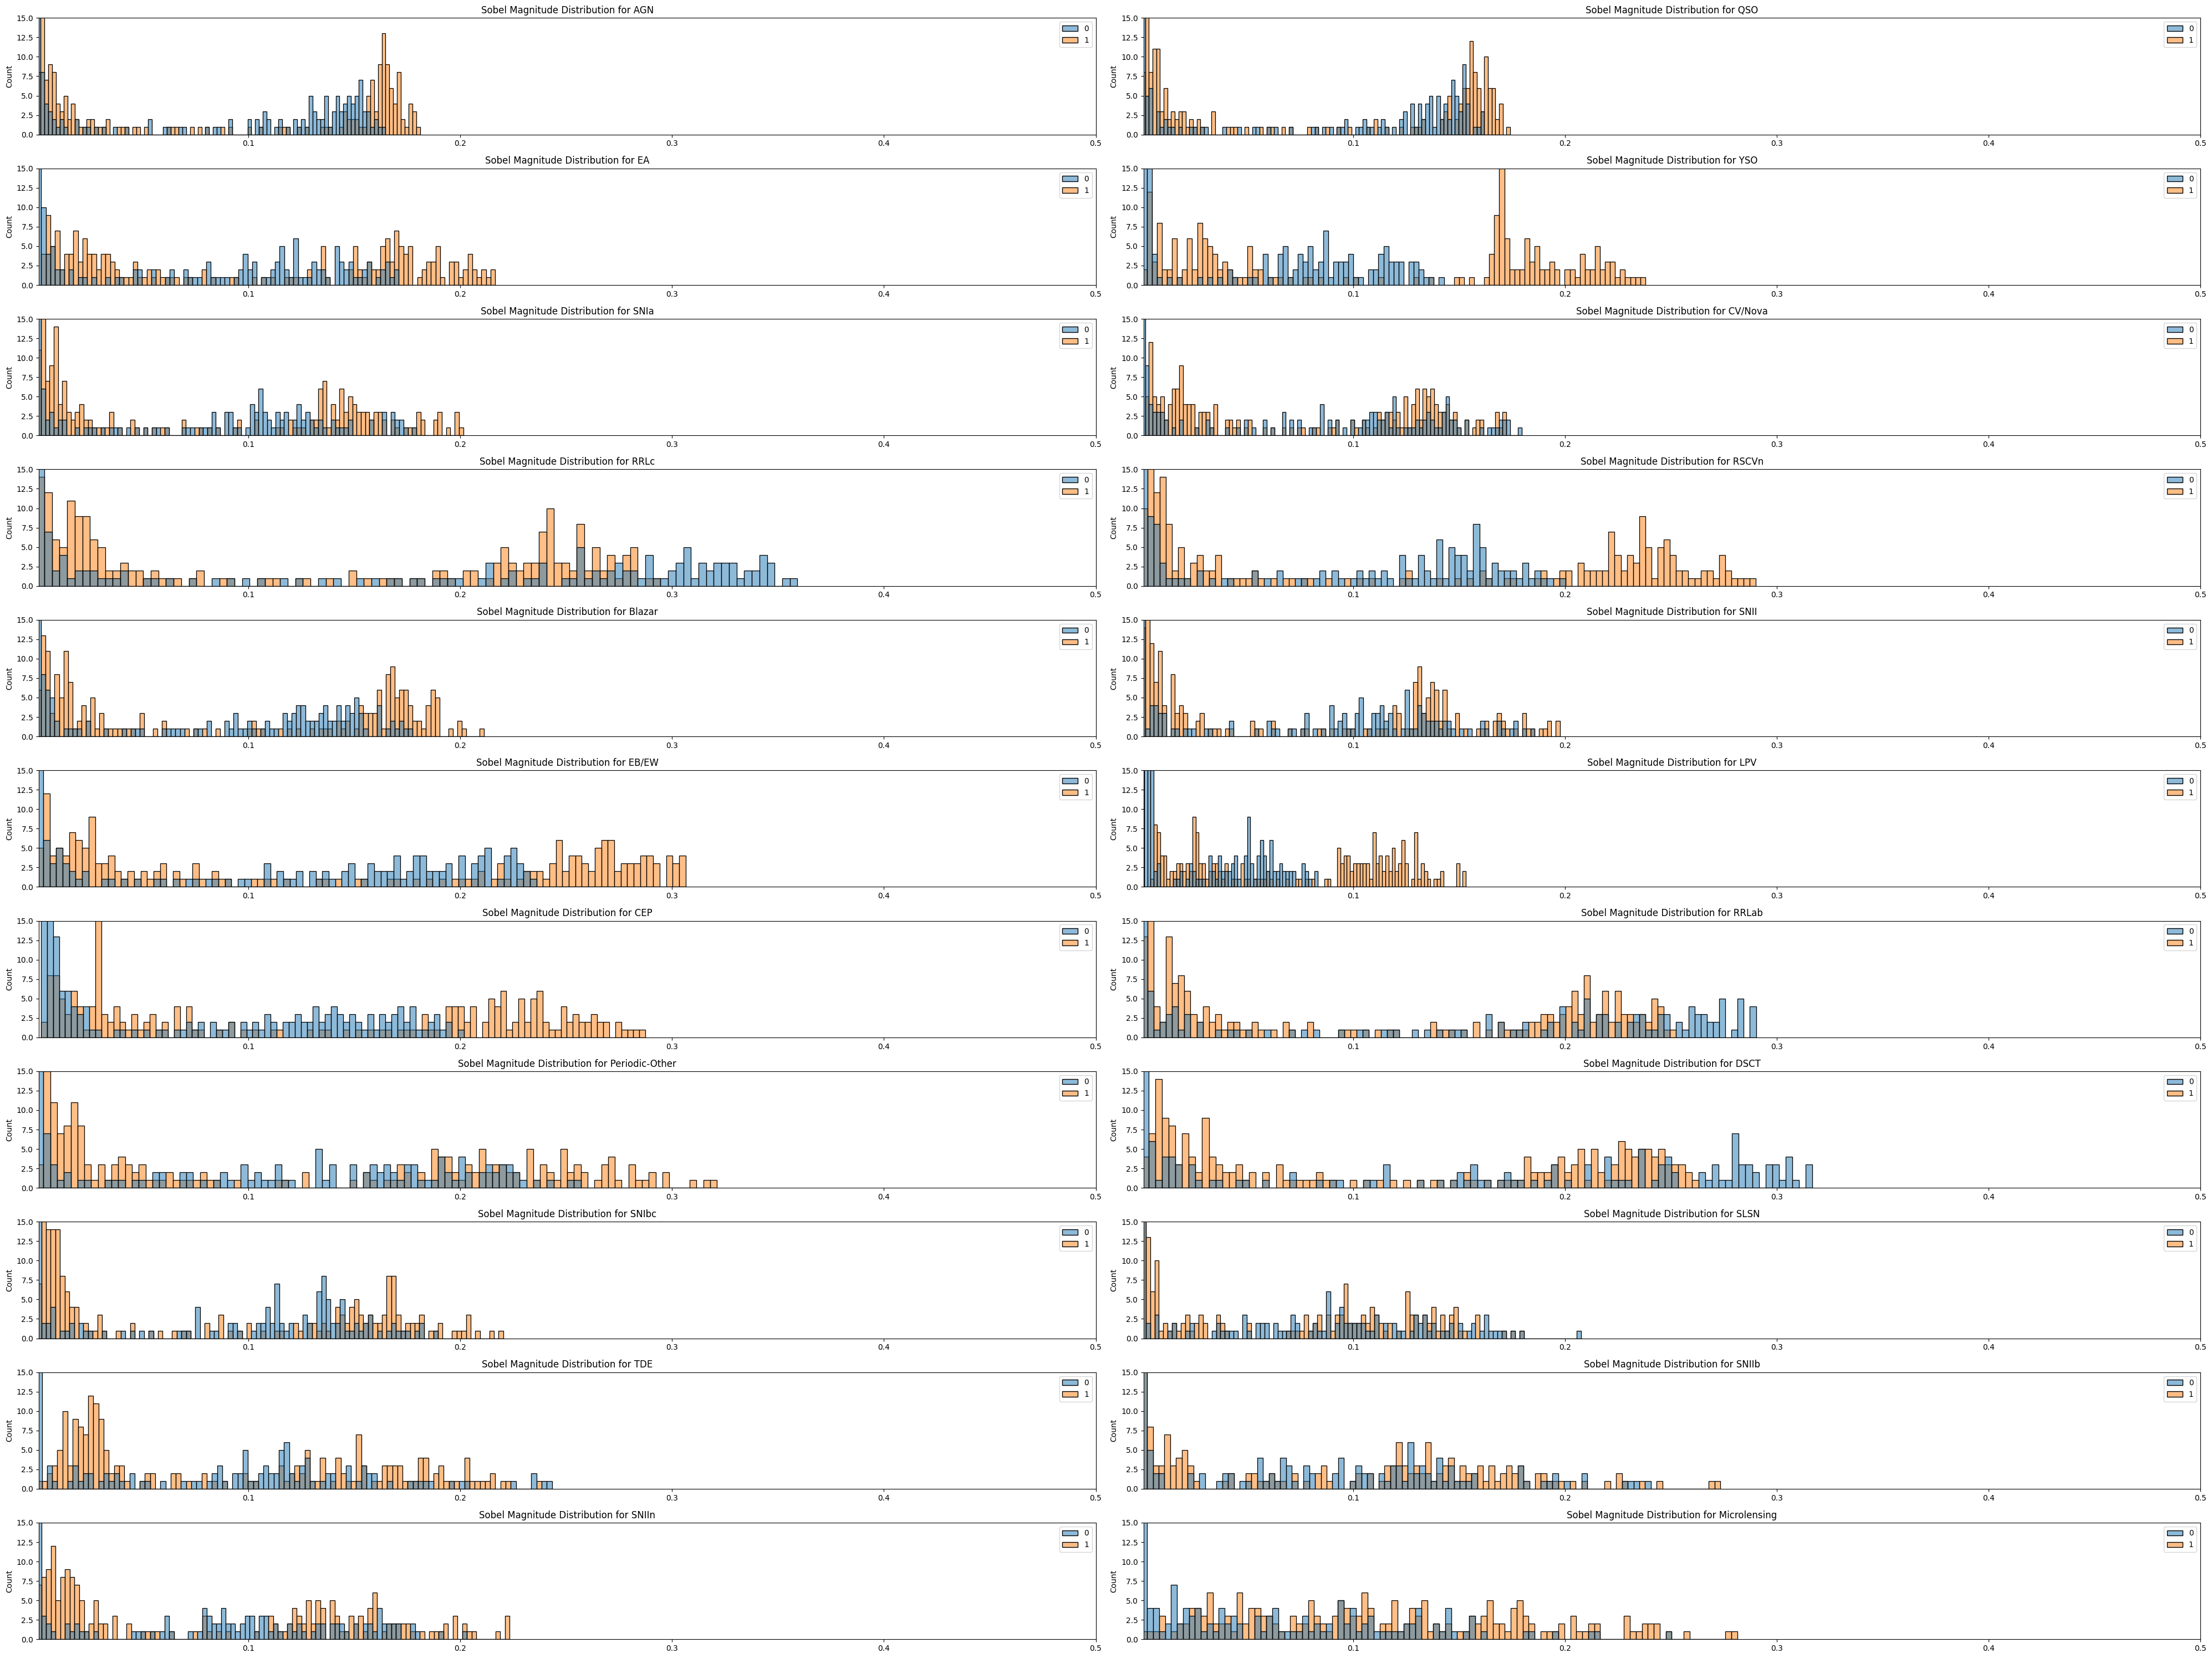

In [ ]:

sobel.plot_mag(xlim = (0.001,0.5), ylim = (0,15))

In [ ]:
#sobel.plot_hor(xlim = (0.0,0.1), ylim = (0,15))

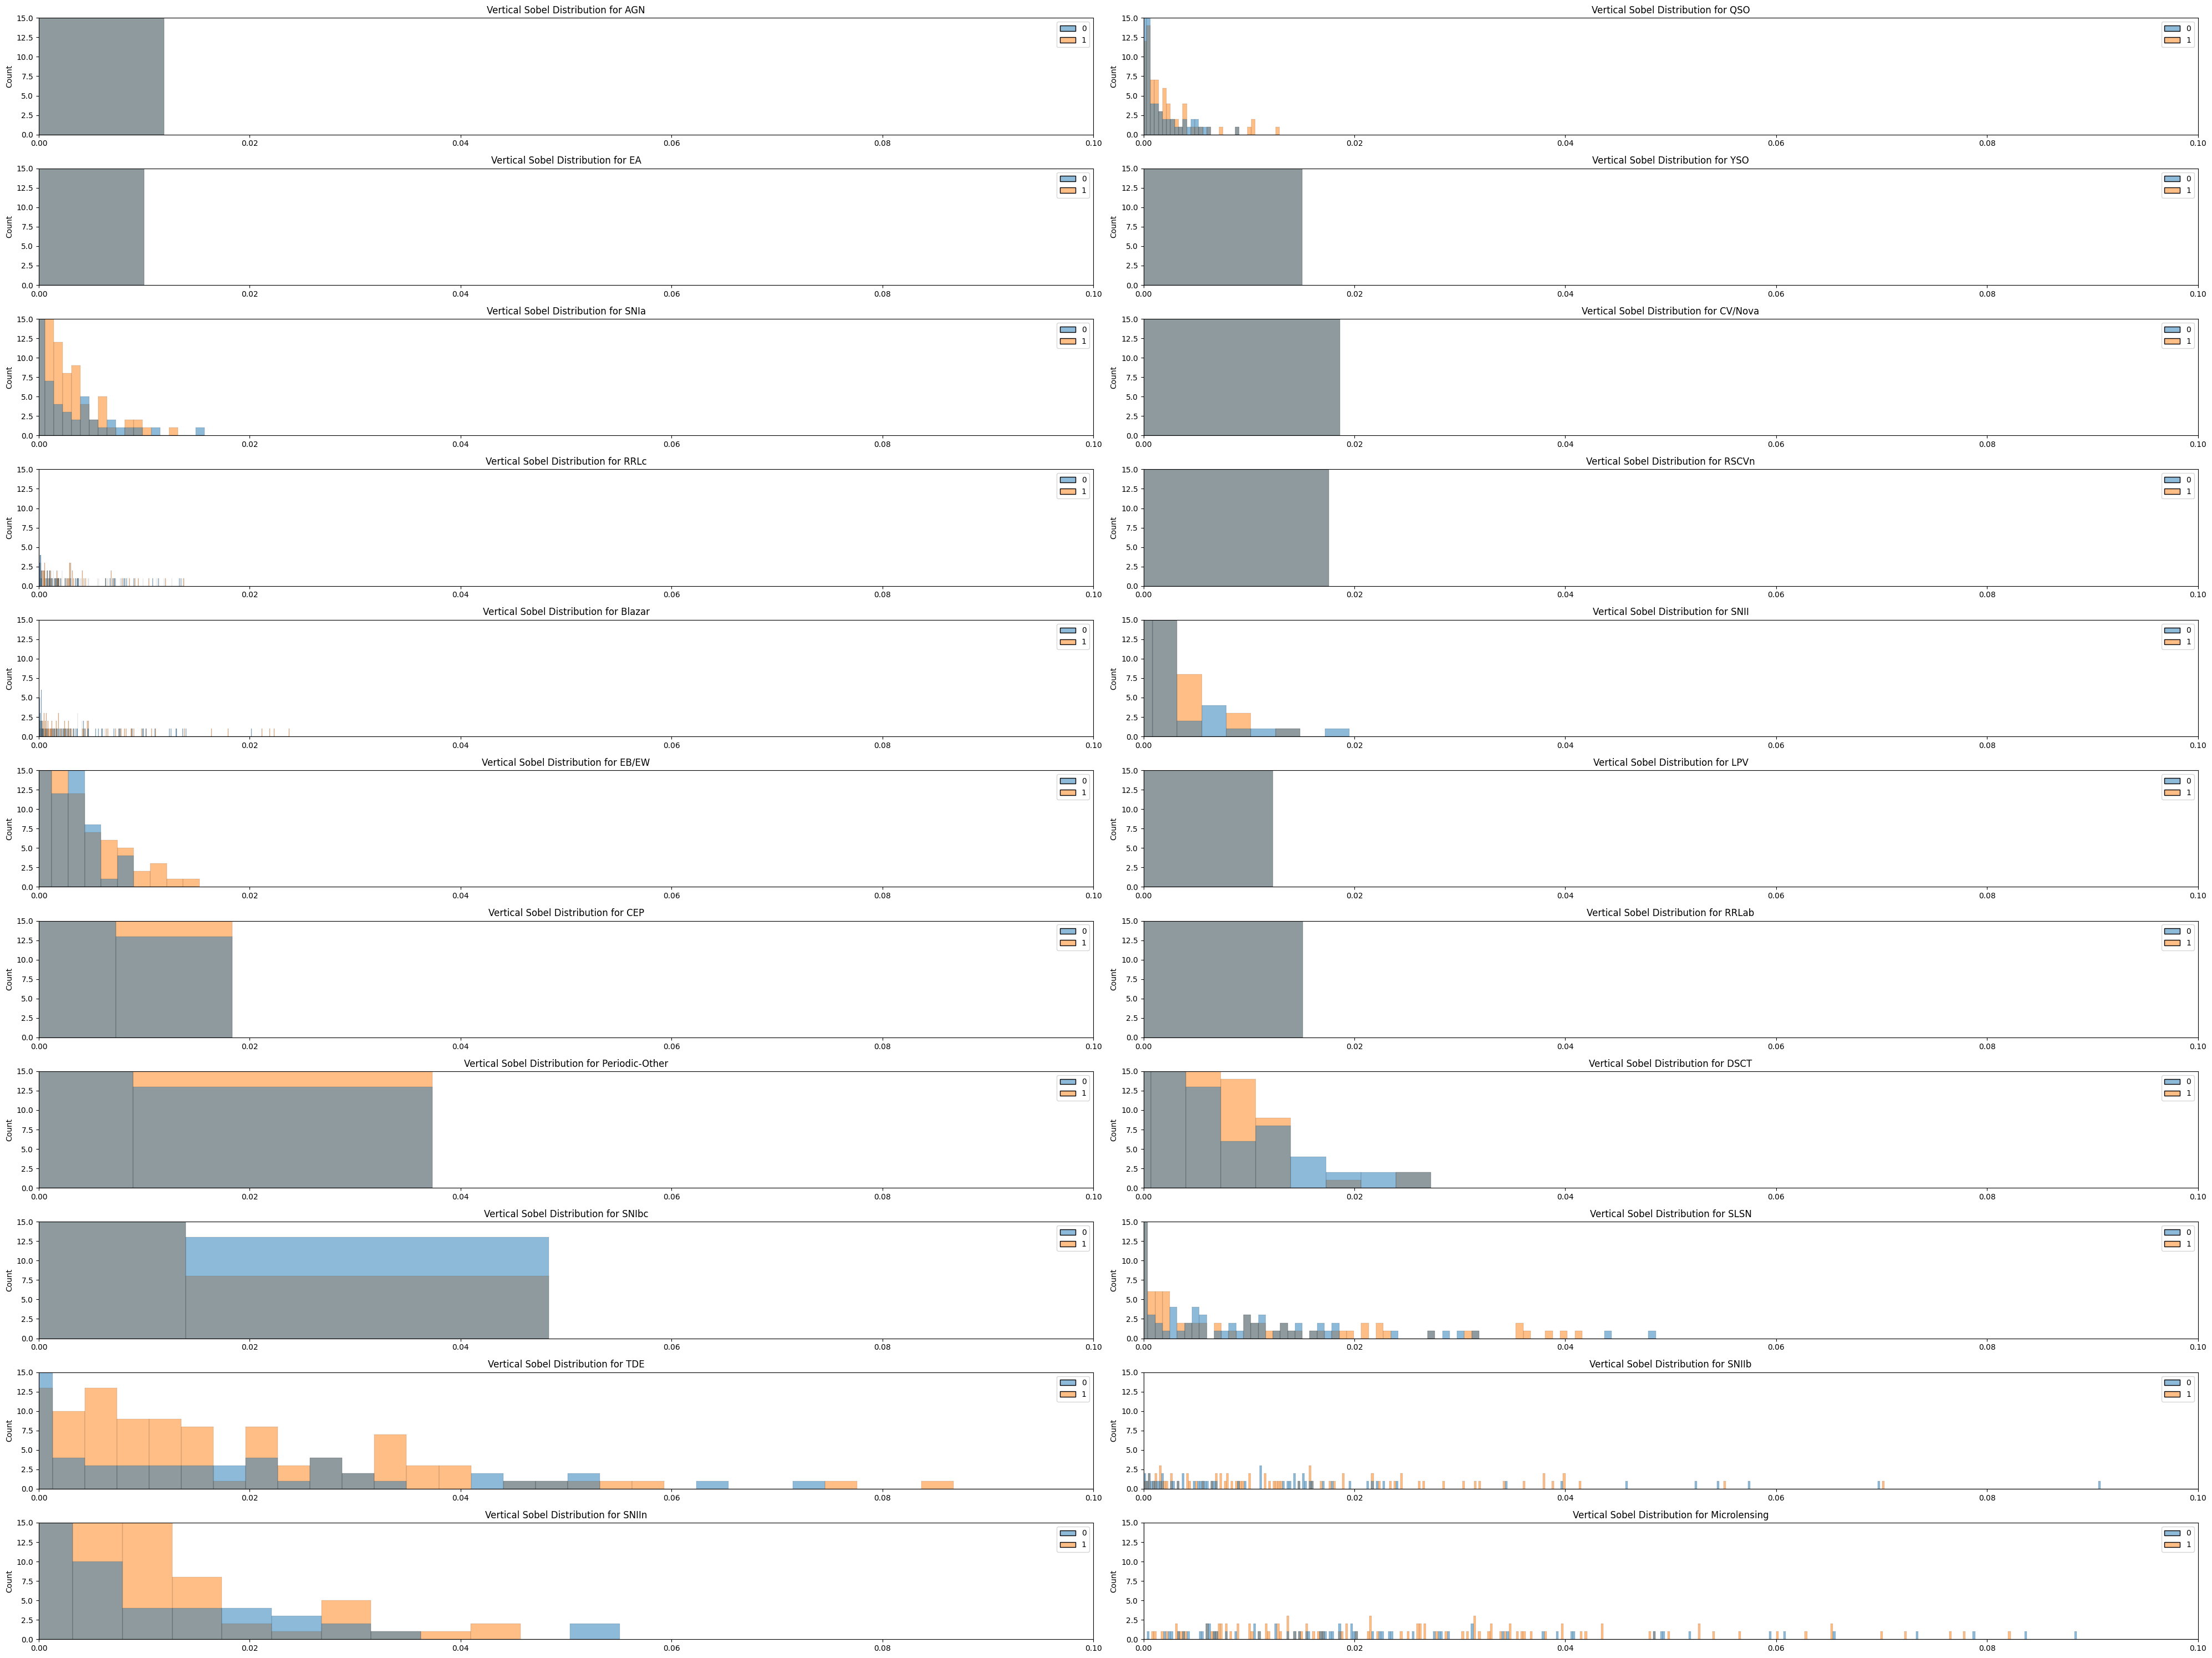

In [ ]:
sobel.plot_vertical(xlim = (0.0,0.1), ylim = (0,15))

In [ ]:
asdfad

NameError: name 'asdfad' is not defined

In [ ]:

from scipy import ndimage, datasets
n = 0 # np.random.randint(0,32)
signal = b1['data'][n,:,:].detach().cpu().numpy()
signal_mask = b1['mask'][n,:,:].detach().cpu().numpy()

sobel_h = ndimage.sobel(signal, 0) * (signal!=0) # horizontal gradient
sobel_v = ndimage.sobel(signal, 1)  * (signal!=0)  # vertical gradient
print(sobel_h.shape)



NameError: name 'b1' is not defined

In [ ]:
from torchvision.transforms import Compose
import seaborn as sns
from src.augmentations import LightCurveTransform as LC
transform = Compose([LC.RandomSobelFilterMask(filter_type = 'horizontal',keep = 'below',threshold_range=(0.1,0.101))])

In [ ]:
target = None
preds_out = None

count = 0
import matplotlib.pyplot as plt
from scipy import ndimage, datasets
import torch
from copy import deepcopy
sobel_h_list = []
sobel_v_list = []
magnitude_list = []

for b1 in tqdm(ql):
    #b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
    #print(b1['data'].squeeze(0).shape)
    for key,value in b1.items():
        b1[key] = value.squeeze(0)

    t = b1['labels']
    item = b1
    copied = deepcopy(item)
    test = transform(copied)
    #fig,ax = plt.subplots(1,2)
    #sns.heatmap(item['mask'],ax = ax[0])
    #sns.heatmap(test['mask'],ax = ax[1])
    #plt.show()
    if count > 10:
        break
    count +=1



 14%|█▍        | 11/80 [00:00<00:03, 20.12it/s]


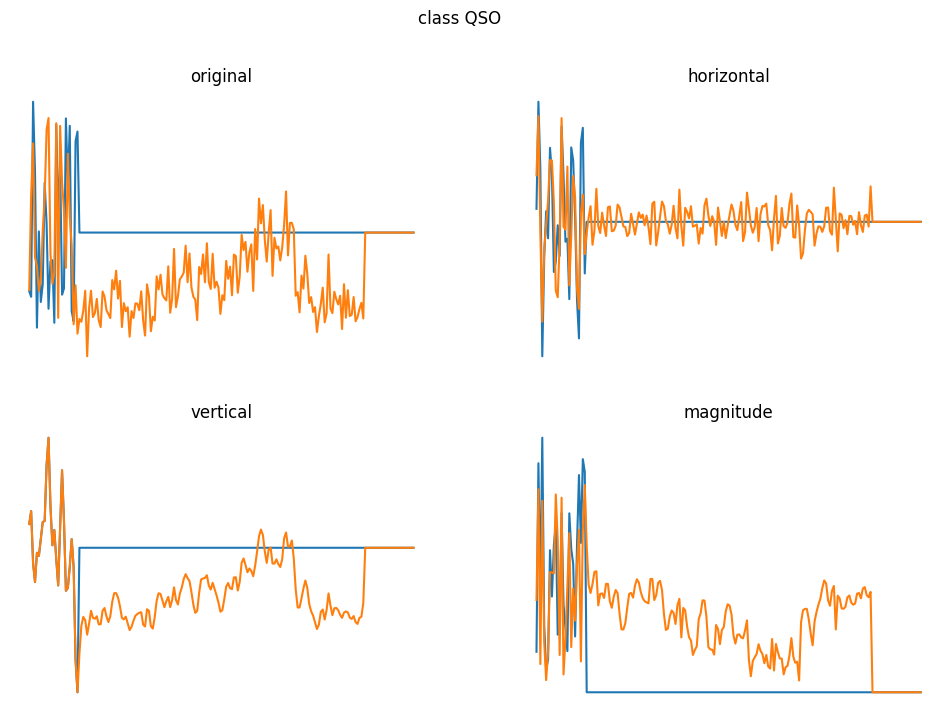

<Axes: >

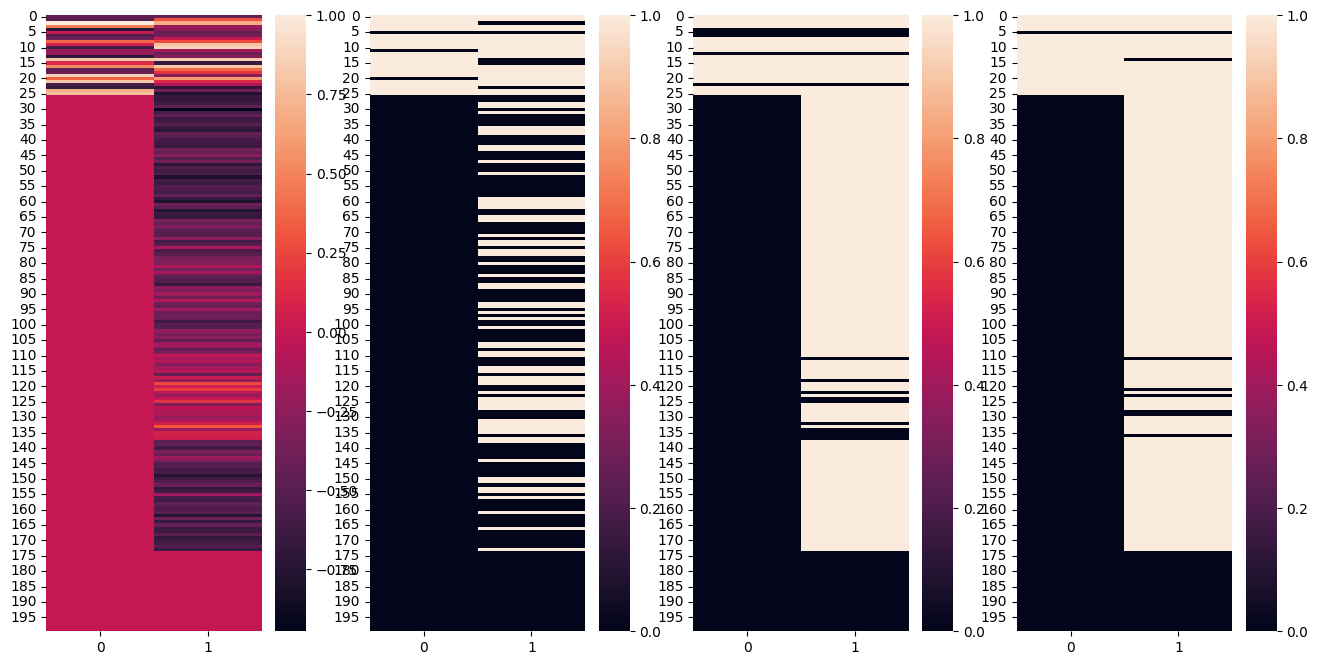

In [ ]:
import seaborn as sns
magnitude = np.sqrt(sobel_h**2 + sobel_v**2)  * (signal!=0)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plt.gray()  # show the filtered result in grayscale
axs[0, 0].plot(signal)
axs[0, 1].plot(sobel_h)
axs[1, 0].plot(sobel_v)
axs[1, 1].plot(magnitude)

titles = ["original", "horizontal", "vertical", "magnitude"]
for i, ax in enumerate(axs.ravel()):
    ax.set_title(titles[i])
    ax.axis("off")
plt.suptitle(f'class {list(dict.keys())[b1['labels'][n].int()]}')
plt.show()

fig,ax = plt.subplots(1,4,figsize = (16,8))
sns.heatmap(signal/signal.max() * (signal !=0),ax = ax[0])
sns.heatmap((abs(sobel_h/sobel_h.max()* (signal !=0))>1e-1)& signal_mask,ax = ax[1])
sns.heatmap((abs(sobel_v/sobel_v.max()* (signal !=0))>1e-1) & signal_mask,ax = ax[2])
sns.heatmap((((magnitude/magnitude.max()* (signal !=0))> 1e-1) & signal_mask),ax = ax[3])


In [ ]:
magnitude_list.shape

torch.Size([0])

,class,indexes
0,0,"[57, 58, 59, 60, 61, 62, 63, 64, 71, 72, 73, 7..."
1,1,"[144, 145, 146, 147, 148, 149, 150, 151, 152, ..."
2,2,"[13, 14, 15, 16, 17, 18, 19, 128, 129, 130, 13..."
3,3,"[106, 107, 108, 109, 110, 111, 112, 113, 308, ..."
4,4,"[65, 66, 67, 68, 69, 70, 452, 453, 454, 455, 4..."
5,5,"[239, 240, 241, 242, 243, 244, 245, 246, 247, ..."
6,6,"[8, 9, 10, 11, 12, 78, 79, 80, 81, 82, 83, 84,..."
7,7,"[51, 833, 834, 835, 1271, 1272, 1273, 1274, 13..."
8,8,"[47, 48, 49, 50, 52, 53, 54, 55, 56, 91, 92, 9..."
9,9,"[353, 354, 355, 448, 462, 783, 784, 785, 786, ..."


In [ ]:
asdfasf

NameError: name 'asdfasf' is not defined

asdfadsf

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d, gaussian_filter
import seaborn as sns
rng = np.random.default_rng()
signal = b1['data'][12,:,0]
#signal = signal[signal.nonzero()]
signal = signal.detach().cpu().numpy()
y3 = gaussian_filter1d(signal, 0.02)
y6 = gaussian_filter1d(signal, 0.05)

y3 = (signal != 0)*y3
plt.plot(signal, 'k', label='original data',alpha = 0.5)
plt.plot(y3, '--', label='filtered, sigma=3', color = 'red')
plt.plot(y6, ':', label='filtered, sigma=1', color = 'blue')
plt.legend()

plt.show()

fig,ax = plt.subplots(1,2,figsize = (12,4))
rng = np.random.default_rng()
signal = b1['data'][12,:,:]
#signal = signal[signal.nonzero()]
signal = signal.detach().cpu().numpy()
y3 = gaussian_filter(signal, 0.5) * (signal !=0)


sns.heatmap(signal/signal.max(),ax = ax[0],cmap = 'viridis')
sns.heatmap(y3/y3.max(),ax = ax[1],cmap = 'viridis')

plt.legend()

plt.show()





In [ ]:
from scipy import ndimage, datasets

signal = b1['data'][1,:,:].detach().cpu().numpy()

sobel_h = ndimage.sobel(signal, 0)  # horizontal gradient
sobel_v = ndimage.sobel(signal, 1)  # vertical gradient
print(sobel_h.shape)

magnitude = np.sqrt(sobel_h**2 + sobel_v**2)
#magnitude *= 255.0 / np.max(magnitude)  # normalization
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plt.gray()  # show the filtered result in grayscale
axs[0, 0].plot(signal)
axs[0, 1].plot(sobel_h)
axs[1, 0].plot(sobel_v)
axs[1, 1].plot(magnitude)
plt.legend(['signal','sobel_h','sobel_v','mag'])

titles = ["original", "horizontal", "vertical", "magnitude"]
for i, ax in enumerate(axs.ravel()):
    ax.set_title(titles[i])
    ax.axis("off")
plt.show()

fig,ax = plt.subplots(1,4,figsize = (16,8))
sns.heatmap(signal/signal.max() * (signal !=0),ax = ax[0])
sns.heatmap(sobel_h/sobel_h.max()* (signal !=0),ax = ax[1])
sns.heatmap(sobel_v/sobel_v.max()* (signal !=0),ax = ax[2])
sns.heatmap(magnitude/magnitude.max()* (signal !=0),ax = ax[3])

In [ ]:
def big_group_plot_umap(ax, umap_result, numeric_labels, num_classes, title):
    colors = ['cyan','yellow','magenta']
    transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
    }
    stochastic =  {
        "AGN": 0,
        "QSO": 1,
        "YSO": 3,
        "CV/Nova": 5,
        "Blazar": 8,
    }
    periodic =  {
        "EA": 2,
        "RRLc": 6,
        "RSCVn": 7,
        "EB/EW": 10,
        "LPV": 11,
        "CEP": 12,
        "RRLab": 13,
        "Periodic-Other": 14,
        "DSCT": 15,
    }

    for i in range(num_classes):
        class_indices = numeric_labels == i
        color = colors[0] if i in transient.values() else (colors[1] if i in stochastic.values() else colors[2])
        ax.scatter(x=umap_result[class_indices, 0], y=umap_result[class_indices, 1],s=7, color=color,alpha = 0.45)


    ax.set_facecolor('black')

    ax.set_title(title)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    plt.legend(['transient', 'stochastic','periodic'])



In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(25, 25))

big_group_plot_umap(axs, umap_result, target, 21,  'UMAP Visualization - concatenated embeddings ')